In [ ]:
import os
import pandas as pd
import keras
import tensorflow
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
#import contextily as ctx
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import statsmodels.api as sm
#tensorflow.config.run_functions_eagerly(True)

In [ ]:
df = pd.read_excel('/content/sample_data/amostras_inferenciadas.xlsx', engine='openpyxl', sheet_name='18_02_2020')

In [ ]:
df.head(1)

,ID,AT,AC,OFERTA,VC,intervalo,UNI,"UNIx0,8 + ITBI","UNIx0,9 + ITBI",VP,...,ZH,PAV,UNI-PRA,CC,TIPO,END,BAIRRO,FONTE / IF,longitude,latitude
0,1,700.0,560,2100000.0,1481028.0,501-700,884.0,707.2,795.6,1,...,4,1,145.3827,1,GALPÃO,"AV VEREADOR DA COSTA RIOS, 1111",CENTRO,CIOFFI IMOVEIS,-45.930455,-22.245445


In [ ]:
df.columns

Index(['ID', 'AT', 'AC', 'OFERTA', 'VC', 'intervalo', 'UNI', 'UNIx0,8 + ITBI',
       'UNIx0,9 + ITBI', 'VP', 'VS', 'OV', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6',
       'Z7', 'Z8', 'Z9', 'ITBI/OF', 'ZH', 'PAV', 'UNI-PRA', 'CC', 'TIPO',
       'END', 'BAIRRO', 'FONTE / IF', 'longitude', 'latitude'],
      dtype='object')

In [ ]:
# Limpeza básica dos dados
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('unix0,9_+_itbi', 'target')
df['tipo'] = df['tipo'].str.replace(' ', '').str.lower()

# Tratamento de valores faltantes e inconsistências
df.replace("-", pd.NA, inplace=True)
df.dropna(inplace=True)
df['pav'] = df['pav'].astype(int)
df.loc[df['pav'] == 2, 'pav'] = 1

In [ ]:
# Renomear colunas para melhor legibilidade
rename_dict = {
    'cc': 'corredor_comercial',
    'vp': 'via_principal',
    'vs': 'via_secundaria',
    'ov': 'outros_vias',
    'itbi/of': 'itbi_of',
}
df = df.rename(columns=rename_dict)


In [ ]:
#remove outliers
#df = df[df['target'] < 10000]
#df = df[df['target'] > 200]

In [ ]:
# converte lat e long para utm
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs='EPSG:4326')
gdf = gdf.to_crs(epsg=31983)  # SIR
df['x'] = gdf.geometry.x
df['y'] = gdf.geometry.y


In [ ]:
df = df.drop(columns=['longitude', 'latitude', 'id', 'intervalo', 'unix0,8_+_itbi', 'uni', 'fonte_/_if', 'end', 'uni-pra', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'bairro'])


In [ ]:
kml_path = "/content/sample_data/zoneamento.kml"
gdf_kml = gpd.read_file(kml_path, driver='KML')


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'zoneamento.kml': 'dissolved' (default), 'puparetificadissolvido', 'zepam1of', 'zep', 'zeep', 'zoneamentodissolvido'. Specify layer parameter to avoid this warning.
  result = read_func(


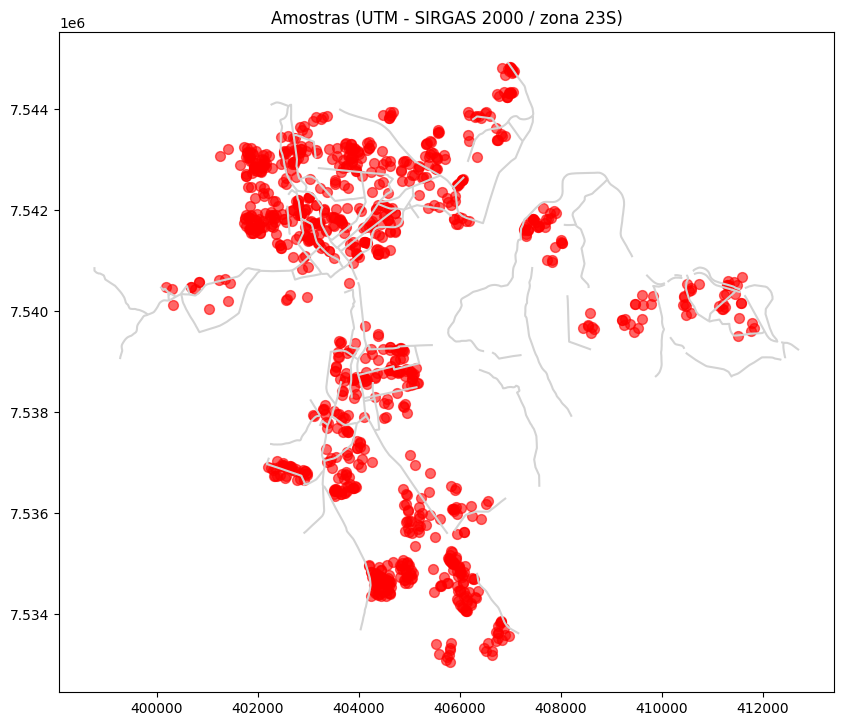

In [ ]:
geometry = [Point(x, y) for x, y in zip(df['x'], df['y'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:31983")  # usa o mesmo CRS do SIRGAS UTM

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_kml.to_crs(epsg=31983).plot(ax=ax, color='lightgrey', edgecolor='black')
gdf_points.plot(ax=ax, color='red', markersize=50, alpha=0.6)

plt.title("Amostras (UTM - SIRGAS 2000 / zona 23S)")
plt.show()

In [ ]:
# add new features to df
df['ratio_area'] = (df['ac'] / df['at']).astype(float)

In [ ]:
df.columns

Index(['at', 'ac', 'oferta', 'vc', 'target', 'via_principal', 'via_secundaria',
       'outros_vias', 'itbi_of', 'zh', 'pav', 'corredor_comercial', 'tipo',
       'x', 'y', 'ratio_area'],
      dtype='object')

In [ ]:
## Tratamento dos dados categóricos
categorical_features = ['zh', 'tipo']
numerical_features = ['at', 'ac','vc','oferta','ratio_area']
binary_features = ['via_principal', 'via_secundaria', 'outros_vias', 'itbi_of', 'pav']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])


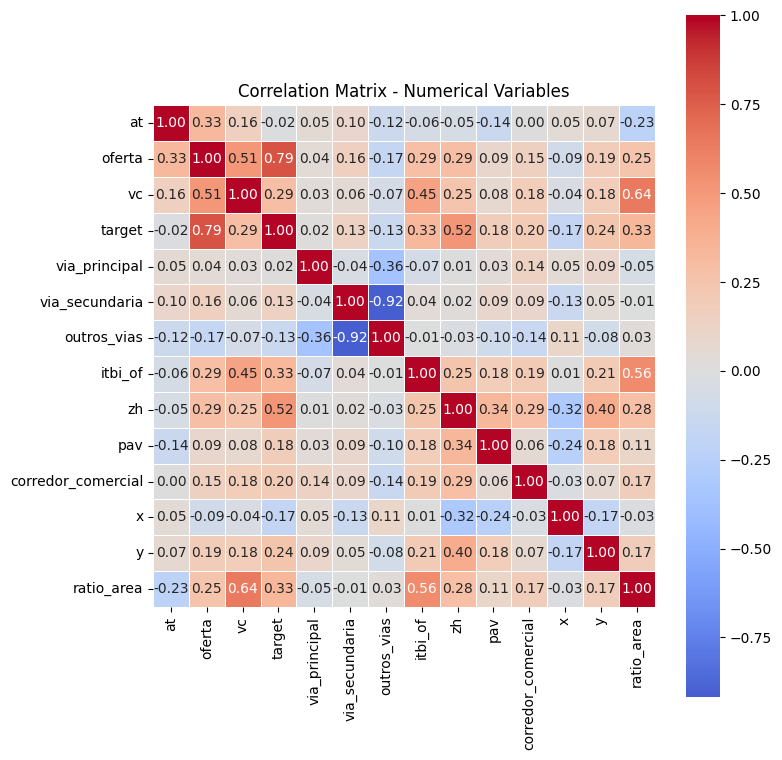

In [ ]:
# Calculate correlation matrix excluding categorical variables
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Plot correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

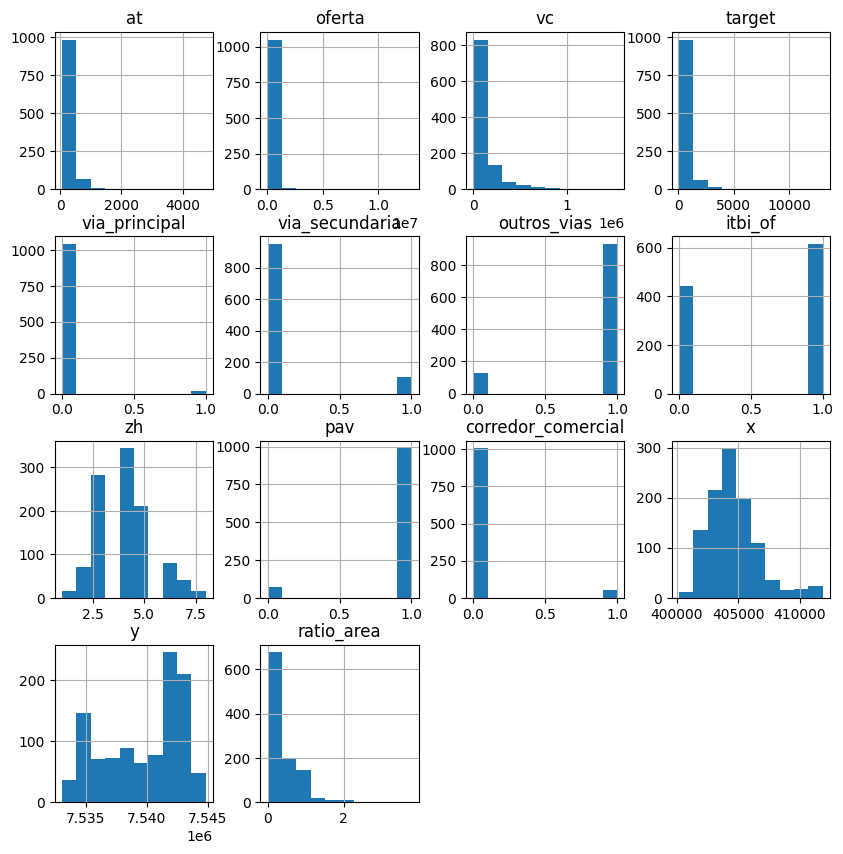

In [ ]:
# plot histogram of each feature
df.hist(figsize=(10,10))
plt.show()

In [ ]:
def plot_regression_diagnostics(results):
    """
    Gera gráficos de diagnóstico de regressão a partir dos resultados do modelo.

    results: dict retornado pelo build_deep_model, contendo:
        - 'y_val'
        - 'X_val'
        - 'model'
    """
    y_val = results['y_val'].flatten()
    X_val = results['X_val']
    y_pred = results['model'].predict(X_val).flatten()

    df_result = pd.DataFrame({
        'Y': y_val,
        'Y_est': y_pred
    })
    df_result['r'] = df_result['Y'] - df_result['Y_est']
    df_result['rabs'] = df_result['r'].abs()

    r_mean = df_result['r'].mean()
    r_std = df_result['r'].std()
    r2 = r2_score(df_result['Y'], df_result['Y_est'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # --- 1. Y vs Y_est ---
    sns.scatterplot(data=df_result, x='Y', y='Y_est', ax=axes[0], color='green')
    axes[0].plot([df_result.Y.min(), df_result.Y.max()],
                 [df_result.Y.min(), df_result.Y.max()],
                 color='red', linestyle='--')
    axes[0].set_title(f'Y vs Y_est (R²={100*r2:.1f}%)')

    # --- 2. Resíduos vs Y ---
    sns.scatterplot(data=df_result, x='Y', y='r', ax=axes[1], color='orange')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title("Resíduos vs Y")

    # --- 3. Resíduos vs Y_est ---
    sns.scatterplot(data=df_result, x='Y_est', y='r', ax=axes[2], color='blue')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title("Resíduos vs Y_est")

    # --- 4. Distribuição dos resíduos ---
    sns.histplot(df_result['r'], kde=True, bins=30, ax=axes[3], color='purple')
    axes[3].set_title(f"Distribuição dos resíduos\nMédia={r_mean:.2f}, Desv={r_std:.2f}")
    axes[3].axvline(r_mean, color='red', linestyle='--')
    axes[3].axvline(r_mean + r_std, color='red', linestyle=':')
    axes[3].axvline(r_mean - r_std, color='red', linestyle=':')

    # --- 5. QQ-plot dos resíduos ---
    sm.qqplot(df_result['r'], line='45', fit=True, ax=axes[4])
    axes[4].set_title("QQ-plot dos resíduos")

    # --- 6. Opcional: Resíduos vs 1ª feature ---
    if X_val is not None:
        if isinstance(X_val, pd.DataFrame):
            feature_name = X_val.columns[0]
            sns.scatterplot(x=X_val.iloc[:, 0], y=df_result['r'], ax=axes[5], color='brown')
            axes[5].axhline(0, color='red', linestyle='--')
            axes[5].set_title(f"Resíduos vs {feature_name}")
        else:
            axes[5].axis("off")
    else:
        axes[5].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
def plot_regression_diagnostics_real(results, y_scaler=None, original_X=None):
    """
    Gera gráficos de diagnóstico de regressão na escala original do target.

    Parameters:
    - results: dict retornado pelo build_deep_model, contendo:
        - 'y_val' (numpy array 2D ou 1D)
        - 'X_val' (numpy array)
        - 'model' (Keras model)
    - y_scaler: scaler usado para escalar y (MinMaxScaler ou StandardScaler), opcional
    - original_X: DataFrame original de features antes do preprocessor, opcional
    """
    X_val = results['X_val']
    y_val = results['y_val']

    # Desescalar y se houver scaler
    if y_scaler is not None:
        y_val = y_scaler.inverse_transform(y_val.reshape(-1,1)).flatten()
        y_pred = y_scaler.inverse_transform(results['model'].predict(X_val)).flatten()
    else:
        y_val = y_val.flatten()
        y_pred = results['model'].predict(X_val).flatten()

    # Criar DataFrame com resultados
    df_result = pd.DataFrame({
        'Y': y_val,
        'Y_est': y_pred
    })
    df_result['r'] = df_result['Y'] - df_result['Y_est']
    df_result['rabs'] = df_result['r'].abs()

    r_mean = df_result['r'].mean()
    r_std = df_result['r'].std()
    r2 = r2_score(df_result['Y'], df_result['Y_est'])

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # 1. Y vs Y_est
    sns.scatterplot(data=df_result, x='Y', y='Y_est', ax=axes[0], color='green')
    axes[0].plot([df_result.Y.min(), df_result.Y.max()],
                 [df_result.Y.min(), df_result.Y.max()],
                 color='red', linestyle='--')
    axes[0].set_title(f'Y vs Y_est (R²={100*r2:.1f}%)')

    # 2. Resíduos vs Y
    sns.scatterplot(data=df_result, x='Y', y='r', ax=axes[1], color='orange')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title("Resíduos vs Y")

    # 3. Resíduos vs Y_est
    sns.scatterplot(data=df_result, x='Y_est', y='r', ax=axes[2], color='blue')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title("Resíduos vs Y_est")

    # 4. Distribuição dos resíduos
    sns.histplot(df_result['r'], kde=True, bins=30, ax=axes[3], color='purple')
    axes[3].set_title(f"Distribuição dos resíduos\nMédia={r_mean:.2f}, Desv={r_std:.2f}")
    axes[3].axvline(r_mean, color='red', linestyle='--')
    axes[3].axvline(r_mean + r_std, color='red', linestyle=':')
    axes[3].axvline(r_mean - r_std, color='red', linestyle=':')

    # 5. QQ-plot dos resíduos
    sm.qqplot(df_result['r'], line='45', fit=True, ax=axes[4])
    axes[4].set_title("QQ-plot dos resíduos")

    # 6. Resíduos vs primeira feature original, se fornecida
    if original_X is not None:
        feature_name = original_X.columns[0]
        sns.scatterplot(x=original_X.iloc[results['X_val_idx'], 0],
                        y=df_result['r'], ax=axes[5], color='brown')
        axes[5].axhline(0, color='red', linestyle='--')
        axes[5].set_title(f"Resíduos vs {feature_name}")
    else:
        axes[5].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
def linear_model(X, y, random_seed, callbacks, adam_initial_lr, adam_lr_decay, epochs):
    keras.utils.set_random_seed(random_seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    grid_results = []
    best_val_loss = float('inf')

    activations = ["linear"]
    for act in activations:
        print(f"\n=== Ativação: {act} ===")
        fold = 1
        fold_results = []

        for train_index, val_index in kf.split(X,y):
            print("Treinamento fold", fold)
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            optimizer = keras.optimizers.Adam(
                learning_rate=adam_initial_lr,
                weight_decay=adam_lr_decay,
            )

            model = keras.Sequential()
            model.add(keras.layers.InputLayer(shape=(X.shape[1],)))
            model.add(keras.layers.Dense(1, activation='linear'))

            model.compile(
                optimizer=optimizer,
                loss="mean_squared_error",
                metrics=["mse"]
            )

            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                verbose=0,
                callbacks=callbacks,
                batch_size=128
            )

            score = model.evaluate(X_val, y_val, verbose=0)
            print(f"[{act}] Fold {fold} - Val Loss: {score[0]:.4f}, Val MSE: {score[1]:.4f}")

            # Check if this is a new best model
            if score[0] < best_val_loss:
                best_val_loss = score[0]
                print(f"*** NOVO MELHOR MODELO! Activation: {act}, Fold: {fold}, Val Loss: {score[0]:.4f} ***")

            results = {
                'activation': act,
                'fold': fold,
                'val_loss': score[0],
                'val_mse': score[1],
                'model': model,
                'history': history,
                'X_val': X_val,
                'y_val': y_val
            }

            fold_results.append(results)
            grid_results.append(results)

            fold += 1

        # média de cada ativação
        avg_loss = np.mean([r['val_loss'] for r in fold_results])
        print(f"=== {act} - Média Val Loss: {avg_loss:.4f} ===")

    # pegar o melhor resultado global
    best_model = min(grid_results, key=lambda x: x['val_loss'])
    print(f"\nMelhor ativação: {best_model['activation']} (fold {best_model['fold']}) "
          f"com val_loss={best_model['val_loss']:.4f}")
    return best_model

In [ ]:
def build_best_model(X, y, activations, random_seed, callbacks, adam_initial_lr, adam_lr_decay, epochs):
    keras.utils.set_random_seed(random_seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    grid_results = []
    best_val_loss = float('inf')

    for act in activations:
        print(f"\n=== Ativação: {act} ===")
        fold = 1
        fold_results = []

        for train_index, val_index in kf.split(X, y):
            print("Treinamento fold", fold)
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]

            optimizer = keras.optimizers.Adam(
                learning_rate=adam_initial_lr,
                weight_decay=adam_lr_decay,
            )

            model = keras.Sequential()
            model.add(keras.layers.InputLayer(shape=(X.shape[1],)))
            model.add(keras.layers.Dense(6, activation=act))
            model.add(keras.layers.Dense(1, activation='linear'))

            model.compile(
                optimizer=optimizer,
                loss="mean_squared_error",
                metrics=["mse"]
            )

            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=epochs,
                verbose=0,
                callbacks=callbacks,
                batch_size=128
            )

            score = model.evaluate(X_val, y_val, verbose=0)
            print(f"[{act}] Fold {fold} - Val Loss: {score[0]:.4f}, Val MSE: {score[1]:.4f}")

            # Check if this is a new best model
            if score[0] < best_val_loss:
                best_val_loss = score[0]
                print(f"*** NOVO MELHOR MODELO! Activation: {act}, Fold: {fold}, Val Loss: {score[0]:.4f} ***")

            results = {
                'activation': act,
                'fold': fold,
                'val_loss': score[0],
                'val_mse': score[1],
                'model': model,
                'history': history,
                'X_val': X_val,
                'y_val': y_val
            }
            fold_results.append(results)
            grid_results.append(results)

            fold += 1

        # média de cada ativação
        avg_loss = np.mean([r['val_loss'] for r in fold_results])
        print(f"=== {act} - Média Val Loss: {avg_loss:.4f} ===")

    # pegar o melhor resultado global
    best_model = min(grid_results, key=lambda x: x['val_loss'])
    print(f"\nMelhor ativação: {best_model['activation']} (fold {best_model['fold']}) "
          f"com val_loss={best_model['val_loss']:.4f}")
    return best_model

In [ ]:
def build_deep_model(X, y, activations, optimizers, random_seed, callbacks,
                     adam_initial_lr, adam_lr_decay, epochs):
    keras.utils.set_random_seed(random_seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    grid_results = []
    best_val_loss = float('inf')

    for act in activations:
        for opt_name in optimizers:
            print(f"\n---Ativação: {act}, Otimizador: {opt_name} ---")
            fold = 1
            fold_results = []

            for train_index, val_index in kf.split(X, y):
                print("Treinamento fold", fold)
                X_train, X_val = X[train_index], X[val_index]
                y_train, y_val = y[train_index], y[val_index]

                # escolher otimizador
                if opt_name == "adam":
                    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
                        initial_learning_rate=adam_initial_lr,
                        decay_rate=adam_initial_lr,
                        decay_steps=10000
                    )
                    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
                elif opt_name == "rmsprop":
                    optimizer = keras.optimizers.RMSprop(learning_rate=adam_initial_lr)
                else:
                    raise ValueError(f"Otimizador {opt_name} não suportado!")

                model = keras.Sequential([
                    keras.layers.InputLayer(shape=(X.shape[1],)),
                    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4)),
                    keras.layers.Dropout(0.3),
                    keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4)),
                    keras.layers.Dropout(0.2),
                    keras.layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4)),
                    keras.layers.Dense(1, activation='linear')
                ])
                model.compile(
                    optimizer=optimizer,
                    loss="mean_squared_error",
                    metrics=["mse", "mae"]
                )

                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    verbose=0,
                    callbacks=callbacks,
                    batch_size=256
                )

                score = model.evaluate(X_val, y_val, verbose=0)
                print(f"[{act} | {opt_name}] Fold {fold} - Val Loss: {score[0]:.4f}, Val MSE: {score[1]:.4f}")

                if score[0] < best_val_loss:
                    best_val_loss = score[0]
                    print(f"*** NOVO MELHOR MODELO! Activation: {act}, Optimizer: {opt_name}, Fold: {fold}, Val Loss: {score[0]:.4f} ***")

                results = {
                    'activation': act,
                    'optimizer': opt_name,
                    'fold': fold,
                    'val_loss': score[0],
                    'val_mse': score[1],
                    'model': model,
                    'history': history,
                    'X_val': X_val,
                    'y_val': y_val
                }

                fold_results.append(results)
                grid_results.append(results)
                fold += 1

            avg_loss = np.mean([r['val_loss'] for r in fold_results])
            print(f"=== {act} + {opt_name} - Média Val Loss: {avg_loss:.4f} ===")

    # pegar o melhor resultado global
    best_model = min(grid_results, key=lambda x: x['val_loss'])
    print(f"\nMelhor combinação: {best_model['activation']} + {best_model['optimizer']} "
          f"(fold {best_model['fold']}) com val_loss={best_model['val_loss']:.4f}")
    return best_model


In [ ]:
def build_deep_model_pattern_search(
    X, y, activations, optimizers, random_seed, epochs,
    initial_neurons=10, max_layers=5, max_neurons=100,
    step_size=8, reduction_factor=0.5, max_iterations=10
):
    """
    Pattern Search for GPU (Google Colab)
    - Expande a arquitetura em blocos de 8 neurônios
    """
    keras.utils.set_random_seed(random_seed)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    current_architecture = [initial_neurons]
    best_model_info = None
    best_score = float('inf')

    print("=== PATTERN SEARCH (GPU) ===")
    print(f"Arquitetura inicial: {current_architecture}")
    print("=" * 50)

    for iteration in range(max_iterations):
        print(f"\n--- ITERACAO {iteration + 1}/{max_iterations} ---")
        print(f"Arquitetura atual: {current_architecture}")
        print(f"Step size: {step_size}")

        # Avaliar arquitetura atual
        current_score, model_info = train_and_evaluate_simple(
            X, y, current_architecture, activations, optimizers, kf, epochs
        )

        print(f"Score atual: {current_score:.4f}")
        improvement_found = False

        # 1. Tentar aumentar neurônios na última camada (de step_size em step_size)
        if current_architecture[-1] < max_neurons and not improvement_found:
            new_arch = current_architecture.copy()
            new_neurons = min(max_neurons, current_architecture[-1] + int(step_size))
            new_arch[-1] = int(new_neurons)

            print(f"Testando mais neuronios: {current_architecture} -> {new_arch}")

            new_score, new_info = train_and_evaluate_simple(
                X, y, new_arch, activations, optimizers, kf, epochs
            )

            print(f"Score novo: {new_score:.4f} (atual: {current_score:.4f})")

            if new_score < current_score:
                current_architecture = new_arch
                best_model_info = new_info
                improvement_found = True
                print("MELHOROU! Mantendo mais neuronios")

        # 2. Tentar adicionar nova camada (sempre com 8 neurônios)
        if len(current_architecture) < max_layers and not improvement_found:
            new_arch = current_architecture + [8]

            print(f"Testando nova camada: {current_architecture} -> {new_arch}")

            new_score, new_info = train_and_evaluate_simple(
                X, y, new_arch, activations, optimizers, kf, epochs
            )

            print(f"Score novo: {new_score:.4f} (atual: {current_score:.4f})")

            if new_score < current_score:
                current_architecture = new_arch
                best_model_info = new_info
                improvement_found = True
                print("MELHOROU! Mantendo nova camada")

        # Atualizar melhor score global
        if current_score < best_score:
            best_score = current_score
            print(f"NOVO MELHOR SCORE GLOBAL: {best_score:.4f}")

        # 3. Reduzir step_size se não houve melhoria
        if not improvement_found:
            old_step_size = step_size
            step_size = max(1, int(step_size * reduction_factor))
            print(f"Nenhuma melhoria. Reduzindo step_size: {old_step_size} -> {step_size}")

            if step_size < 1:
                print("Step_size muito pequeno. Busca convergiu!")
                break
        else:
            print("Continuando com nova arquitetura...")

    print(f"\n=== BUSCA CONCLUIDA ===")
    print(f"Melhor arquitetura: {current_architecture}")
    print(f"Melhor score: {best_score:.4f}")

    return best_model_info


def train_and_evaluate_simple(X, y, architecture, activations, optimizers, kf, epochs):
    """Treina e avalia de forma simples"""
    best_score = float('inf')
    best_info = None

    print(f"Testando arquitetura: {architecture}")
    print(f"Combinacoes: {len(activations)} ativacoes x {len(optimizers)} otimizadores")

    for i, act in enumerate(activations):
        for j, opt_name in enumerate(optimizers):
            scores = []

            print(f"Combinacao {i*len(optimizers)+j+1}: {act} + {opt_name}")

            for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
                X_train, X_val = X[train_index], X[val_index]
                y_train, y_val = y[train_index], y[val_index]

                # Construir modelo
                model = keras.Sequential()
                model.add(keras.layers.InputLayer(shape=(X.shape[1],)))
                for neurons in architecture:
                    model.add(keras.layers.Dense(int(neurons), activation=act))
                model.add(keras.layers.Dense(1, activation='linear'))

                # Otimizador
                if opt_name == "adam":
                    optimizer = keras.optimizers.Adam(learning_rate=0.001)
                else:
                    optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

                model.compile(optimizer=optimizer, loss="mse")

                # Callbacks por fold
                fold_callbacks = [
                    keras.callbacks.EarlyStopping(
                        monitor="val_loss", patience=30, restore_best_weights=True
                    )
                ]

                # Treinar
                history = model.fit(
                    X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs, verbose=0,
                    callbacks=fold_callbacks,
                    batch_size=32
                )

                # Avaliar
                score = model.evaluate(X_val, y_val, verbose=0)
                scores.append(score)

                print(f"  Fold {fold+1}/5 - Loss: {score:.4f}")

            avg_score = np.mean(scores)
            print(f"  Media: {avg_score:.4f}")

            if avg_score < best_score:
                best_score = avg_score
                best_info = {
                    'activation': act,
                    'optimizer': opt_name,
                    'architecture': architecture,
                    'val_loss': best_score,
                    'model': model,
                    'history': history
                }

    print(f"Melhor combinacao: {best_info['activation']} + {best_info['optimizer']}")
    return best_score, best_info


In [ ]:
# Configurações para treinamento dos modelos
random_seed = 10
learning_rate = 0.01
adam_initial_lr = 0.001
adam_decay_steps = 1000
adam_lr_decay = 0.001
val_loss_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=300, restore_best_weights=True)
epochs = 1000




In [ ]:
# Remove outliers
df = df[df['target'] < 10000]
df = df[df['target'] > 200]

In [ ]:
df.describe()

,at,oferta,vc,target,via_principal,via_secundaria,outros_vias,itbi_of,zh,pav,corredor_comercial,x,y,ratio_area
count,981.000000,9.810000e+02,9.810000e+02,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,981.000000,9.810000e+02,981.000000
mean,290.895025,2.984032e+05,9.757586e+04,660.211278,0.018349,0.104995,0.876656,0.602446,4.221203,0.968400,0.053007,404368.235729,7.539898e+06,0.313348
std,235.740992,3.514697e+05,1.826761e+05,521.918193,0.134277,0.306703,0.328999,0.489642,1.239239,0.175023,0.224162,1799.821300,3.159934e+03,0.467787
min,66.000000,1.800000e+04,0.000000e+00,203.242030,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,400172.990000,7.533155e+06,0.000000
25%,200.000000,1.000000e+05,0.000000e+00,343.701667,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,0.000000,403050.346691,7.536851e+06,0.000000
50%,246.360000,1.800000e+05,0.000000e+00,480.000000,0.000000,0.000000,1.000000,1.000000,4.000000,1.000000,0.000000,404246.560000,7.541347e+06,0.000000
75%,316.000000,3.500000e+05,1.394290e+05,780.284541,0.000000,0.000000,1.000000,1.000000,5.000000,1.000000,0.000000,405376.160906,7.542559e+06,0.666667
max,4750.000000,4.500000e+06,1.542051e+06,5265.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,411828.662842,7.544838e+06,3.774688


In [ ]:
X = df.drop(columns=['target', 'x', 'y'])
y = df['target'].values.reshape(-1, 1)
X_processed = preprocessor.fit_transform(X)

y_scaled = np.log1p(y + 1);

# Configurações dos modelos
activations = ["relu", 'tanh']
optimizers = ["rmsprop", 'adam']

## Treinamento dos Modelos

In [ ]:

# model = build_best_model(X_processed, y_scaled, activations, random_seed,
#                                         callbacks=[val_loss_stopping], adam_initial_lr=adam_initial_lr, adam_lr_decay=adam_lr_decay, epochs=epochs)

In [ ]:
# #Pega os dados do melhor fold
# X_val_best = model['X_val']
# y_val_best = model['y_val']

# # Faz a predição no melhor fold
# y_pred_best = model['model'].predict(X_val_best).flatten()

# # Plota diagnósticos
# plot_regression_diagnostics(model)
# # plot training history
# plt.figure(figsize=(6, 6))
# plt.plot(model['history'].history['loss'], label='Train Loss')
# plt.plot(model['history'].history['val_loss'], label='Val Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()

In [ ]:
#gridsearch for a linear regression model
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# param_grid = {
#     'fit_intercept': [True, False]
# }
# reg = LinearRegression()
# grid_search = GridSearchCV(reg, param_grid, cv=5, scoring='r2')
# grid_search.fit(X_train, y_train)
# best_reg = grid_search.best_estimator_
# y_pred_reg = best_reg.predict(X_test)


In [ ]:
#plot r2, kde and residual of linear  with r2 of best model
#plot_regression_diagnostics(best_reg)


In [ ]:
# lm_model = linear_model(X_processed, y_scaled, random_seed, callbacks=[val_loss_stopping], adam_initial_lr=adam_initial_lr, adam_lr_decay=adam_lr_decay, epochs=epochs)


In [ ]:
# plot_regression_diagnostics(lm_model)

# history = lm_model['history']
# # plot training history
# plt.figure(figsize=(6, 6))
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.xlabel('Epochs')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.show()

In [ ]:
best_model = build_deep_model(
    X=X_processed,
    y=y_scaled,
    activations=activations,
    optimizers=optimizers,
    random_seed=random_seed,
    epochs=epochs,
    callbacks=[val_loss_stopping],
    adam_initial_lr=adam_initial_lr,
    adam_lr_decay=adam_lr_decay
)


---Ativação: relu, Otimizador: rmsprop ---
Treinamento fold 1
[relu | rmsprop] Fold 1 - Val Loss: 0.0392, Val MSE: 0.0312
*** NOVO MELHOR MODELO! Activation: relu, Optimizer: rmsprop, Fold: 1, Val Loss: 0.0392 ***
Treinamento fold 2
[relu | rmsprop] Fold 2 - Val Loss: 0.0301, Val MSE: 0.0215
*** NOVO MELHOR MODELO! Activation: relu, Optimizer: rmsprop, Fold: 2, Val Loss: 0.0301 ***
Treinamento fold 3
[relu | rmsprop] Fold 3 - Val Loss: 0.0254, Val MSE: 0.0172
*** NOVO MELHOR MODELO! Activation: relu, Optimizer: rmsprop, Fold: 3, Val Loss: 0.0254 ***
Treinamento fold 4
[relu | rmsprop] Fold 4 - Val Loss: 0.0314, Val MSE: 0.0231
Treinamento fold 5
[relu | rmsprop] Fold 5 - Val Loss: 0.0258, Val MSE: 0.0173
=== relu + rmsprop - Média Val Loss: 0.0304 ===

---Ativação: relu, Otimizador: adam ---
Treinamento fold 1
[relu | adam] Fold 1 - Val Loss: 0.2895, Val MSE: 0.2743
Treinamento fold 2
[relu | adam] Fold 2 - Val Loss: 0.5824, Val MSE: 0.5666
Treinamento fold 3
[relu | adam] Fold 3 - Va

In [ ]:
plot_regression_diagnostics(best_model)
history = best_model['history']
# plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


In [ ]:
pred_scaled = best_model['model'].predict(X_processed[:10])
pred_original = np.expm1(pred_scaled)
print("Scaled predictions:", pred_scaled.flatten())
print("Original scale:", pred_original.flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Scaled predictions: [6.71752   6.9502883 7.1093736 6.8769507 6.4117966 7.106104  6.168908
 7.0195155 6.918711  6.988593 ]
Original scale: [ 825.7648  1042.4506  1222.381    968.6651   607.9868  1218.3875
  476.66428 1117.2448  1010.0161  1083.1951 ]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


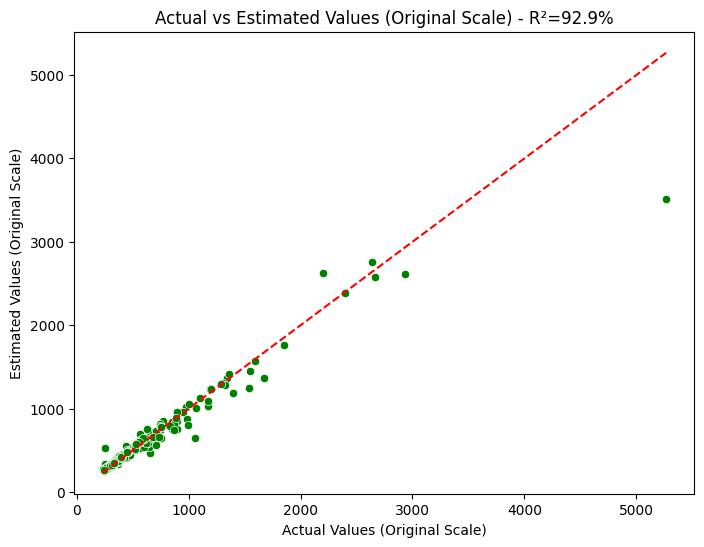

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score
import pandas as pd

# Get data from the best model results (assuming best_model is available)
X_val_scaled = best_model['X_val']
y_val_scaled = best_model['y_val']
model = best_model['model']

# Predict on the scaled validation data
y_pred_scaled = model.predict(X_val_scaled)

# Inverse transform y_val_scaled and y_pred_scaled
# Assuming y was scaled using np.log1p, inverse is np.expm1
y_val_original = np.expm1(y_val_scaled)
y_pred_original = np.expm1(y_pred_scaled)

# Flatten the arrays
y_val_original = y_val_original.flatten()
y_pred_original = y_pred_original.flatten()

# Create a DataFrame for plotting
df_result = pd.DataFrame({
    'Y': y_val_original,
    'Y_est': y_pred_original
})

# Calculate R2 score
r2 = r2_score(df_result['Y'], df_result['Y_est'])

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Y vs Y_est
sns.scatterplot(data=df_result, x='Y', y='Y_est', ax=ax, color='green')
ax.plot([df_result.Y.min(), df_result.Y.max()],
         [df_result.Y.min(), df_result.Y.max()],
         color='red', linestyle='--')
ax.set_title(f'Actual vs Estimated Values (Original Scale) - R²={100*r2:.1f}%')
ax.set_xlabel('Actual Values (Original Scale)')
ax.set_ylabel('Estimated Values (Original Scale)')

plt.show()

In [ ]:
from joblib import dump, load
dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

In [ ]:
#save model to be used in later predictions
best_model['model'].save('best_deep_model.keras')


In [ ]:
#print sklearn version
import sklearn
print(sklearn.__version__)

1.6.1
